In [1]:
# ==========================================================
# CELL 1
# Install required libraries for Kaggle
# ==========================================================

print("Starting cell #1")

!pip install -q transformers scikit-learn pandas openpyxl seaborn
print("Executed cell #1")

Starting cell #1
Executed cell #1


In [2]:
print("Starting cell #2")
# ==========================================================
# CELL 2
# Import all required Python libraries
# ==========================================================

import os
import random
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import WeightedRandomSampler

from transformers import AutoTokenizer, AutoModel
from torch.optim import AdamW

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt
print("Executed cell #2")

Starting cell #2
Executed cell #2


In [3]:
# ==========================================================
# CELL 3
# Set random seeds for reproducibility
# ==========================================================

print("Starting cell #3")


SEED = 42

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Seed set to: {seed}")

set_seed(SEED)
print("Executed cell #3")

Starting cell #3
Seed set to: 42
Executed cell #3


In [4]:
# ==========================================================
# CELL 4
# Check whether GPU is available
# ==========================================================
print("Starting cell #4")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
print("Executed cell #4")

Starting cell #4
Using device: cuda
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
Executed cell #4


In [5]:
# ==========================================================
# CELL 5
# Load dataset splits from Kaggle input or working directory
# ==========================================================
print("Starting cell #5")

from pathlib import Path

def find_file(filename):
    search_roots = [Path("/kaggle/input"), Path("/kaggle/working"), Path(".")]
    for root in search_roots:
        matches = list(root.rglob(filename))
        if matches:
            return str(matches[0])
    raise FileNotFoundError(f"{filename} not found in /kaggle/input, /kaggle/working, or current directory.")

TRAIN_FILE = find_file("train.csv")
VAL_FILE   = find_file("validation.csv")
TEST_FILE  = find_file("test.csv")

print("Train file:", TRAIN_FILE)
print("Validation file:", VAL_FILE)
print("Test file:", TEST_FILE)

train_df = pd.read_csv(TRAIN_FILE)
val_df   = pd.read_csv(VAL_FILE)
test_df  = pd.read_csv(TEST_FILE)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()
print("Executed cell #5")

Starting cell #5
Train file: /kaggle/input/datasets/sajidruetcse21/dataset1/train.csv
Validation file: /kaggle/input/datasets/sajidruetcse21/dataset1/validation.csv
Test file: /kaggle/input/datasets/sajidruetcse21/dataset1/test.csv
Train shape: (56067, 4)
Validation shape: (7929, 4)
Test shape: (16101, 4)
Executed cell #5


In [6]:
# ==========================================================
# CELL 6
# Select label column
# ==========================================================
print("Starting cell #6")

LABEL_COLUMN = "Label"
print("Executed cell #6")

Starting cell #6
Executed cell #6


In [7]:
# ==========================================================
# CELL 7
# Convert emotion labels into numerical form
# ==========================================================
print("Starting cell #7")

label_encoder = LabelEncoder()

train_df[LABEL_COLUMN] = label_encoder.fit_transform(train_df[LABEL_COLUMN])
val_df[LABEL_COLUMN] = label_encoder.transform(val_df[LABEL_COLUMN])
test_df[LABEL_COLUMN] = label_encoder.transform(test_df[LABEL_COLUMN])

num_labels = len(label_encoder.classes_)
print("Emotion classes:", list(label_encoder.classes_))
print("Number of classes:", num_labels)
print("Executed cell #7")

Starting cell #7
Emotion classes: ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']
Number of classes: 6
Executed cell #7


Starting cell #8


/tmp/ipykernel_22/263368284.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


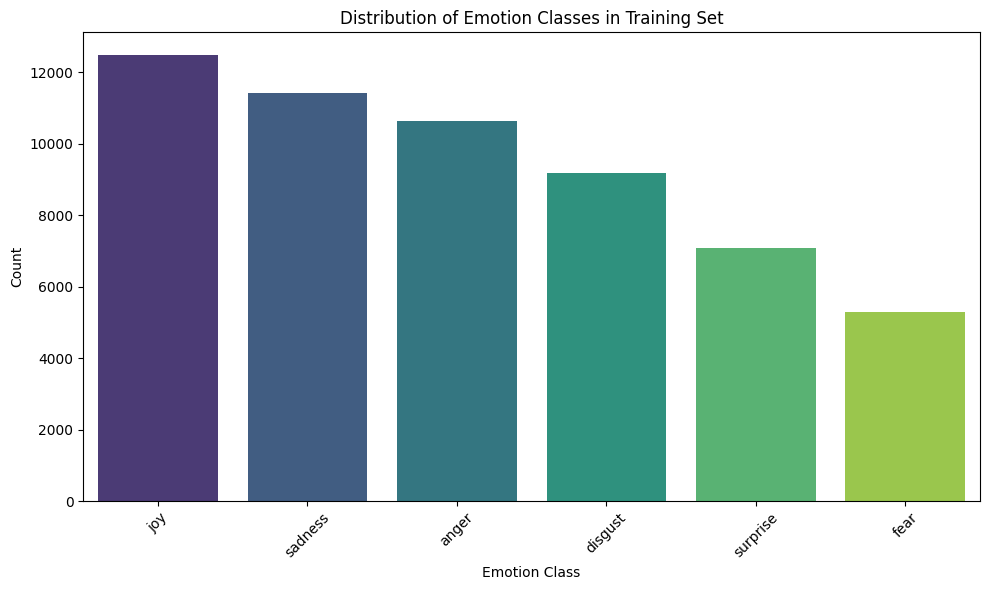

Executed cell #8


In [8]:
# ==========================================================
# CELL 8
# Visualize the distribution of emotion classes in the training data
# ==========================================================
print("Starting cell #8")

label_counts = train_df[LABEL_COLUMN].value_counts()

class_names = label_encoder.inverse_transform(label_counts.index)
label_counts.index = class_names

plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.title("Distribution of Emotion Classes in Training Set")
plt.xlabel("Emotion Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Executed cell #8")

In [9]:
# ==========================================================
# CELL 9
# Compute class weights for imbalanced dataset
# Keep weights on CPU here to avoid early CUDA issues
# ==========================================================
print("Starting cell #9")

ordered_counts_series = label_counts.reindex(label_encoder.classes_)
class_counts_array = ordered_counts_series.values

total_samples = train_df.shape[0]
num_classes = num_labels

raw_class_weights = np.sqrt(total_samples / (num_classes * class_counts_array))
class_weights = torch.tensor(raw_class_weights, dtype=torch.float)

print("Class counts (ordered):", dict(zip(label_encoder.classes_, class_counts_array)))
print("Raw class weights:", class_weights.tolist())
print("Executed cell #9")

Starting cell #9
Class counts (ordered): {'anger': np.int64(10626), 'disgust': np.int64(9169), 'fear': np.int64(5295), 'joy': np.int64(12486), 'sadness': np.int64(11416), 'surprise': np.int64(7075)}
Raw class weights: [0.9377630949020386, 1.009524941444397, 1.3284494876861572, 0.865100085735321, 0.9047343134880066, 1.1492507457733154]
Executed cell #9


In [10]:
# ==========================================================
# CELL 10
# Load tokenizer for multilingual transformer
# ==========================================================
print("Starting cell #10")

MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Executed cell #10")

Starting cell #10


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Executed cell #10


In [11]:
# ==========================================================
# CELL 11
# Custom Dataset class for multilingual aligned emotion data
# ==========================================================
print("Starting cell #11")

class EmotionDataset(Dataset):

    def __init__(self, dataframe, text_columns, label_column, max_length=128):
        self.dataframe = dataframe.reset_index(drop=True)
        self.text_columns = text_columns
        self.label_column = label_column
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        item = {}

        for col in self.text_columns:
            text = str(row[col])

            encoded = tokenizer(
                text,
                truncation=True,
                padding="max_length",
                max_length=self.max_length,
                return_tensors="pt"
            )

            item[f"{col}_input_ids"] = encoded["input_ids"].squeeze(0)
            item[f"{col}_attention_mask"] = encoded["attention_mask"].squeeze(0)

        item["labels"] = torch.tensor(int(row[self.label_column]), dtype=torch.long)
        return item
print("Executed cell #11")

Starting cell #11
Executed cell #11


In [12]:
# ==========================================================
# CELL 12
# Create dataset objects for train, validation, and test
# with all three languages for contrastive learning
# ==========================================================
print("Starting cell #12")

TEXT_LANG_COLUMNS = ["Bengali", "Banglish", "English"]

train_dataset = EmotionDataset(train_df, TEXT_LANG_COLUMNS, LABEL_COLUMN)
val_dataset = EmotionDataset(val_df, TEXT_LANG_COLUMNS, LABEL_COLUMN)
test_dataset = EmotionDataset(test_df, TEXT_LANG_COLUMNS, LABEL_COLUMN)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))
print("Executed cell #12")

Starting cell #12
Train dataset size: 56067
Validation dataset size: 7929
Test dataset size: 16101
Executed cell #12


In [13]:
# ==========================================================
# CELL 13
# Create DataLoaders for batching during training
# Kaggle-safe version for T4 x2 runtime
# ==========================================================
print("Starting cell #13")

BATCH_SIZE = 16
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
PIN_MEMORY = torch.cuda.is_available()

g = torch.Generator()
g.manual_seed(SEED)

current_train_labels = train_df[LABEL_COLUMN].tolist()

class_weights_np = class_weights.cpu().numpy()
sample_weights = [class_weights_np[label] for label in current_train_labels]
sample_weights_tensor = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights_tensor,
    num_samples=len(sample_weights_tensor),
    replacement=True,
    generator=g
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)

print("Batch size:", BATCH_SIZE)
print("Num workers:", NUM_WORKERS)
print("Pin memory:", PIN_MEMORY)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))
print("Executed cell #13")

Starting cell #13
Batch size: 16
Num workers: 2
Pin memory: True
Train batches: 3505
Validation batches: 496
Test batches: 1007
Executed cell #13


In [14]:
# ==========================================================
# CELL 14
# Multilingual emotion model with projection head + learned fusion
# + DataParallel for easiest 2-GPU usage
# ==========================================================
print("Starting cell #14")

class MultilingualEmotionModel(nn.Module):
    def __init__(
        self,
        num_labels,
        model_name="xlm-roberta-base",
        projection_dim=256,
        dropout=0.2
    ):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.projection_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, projection_dim)
        )

        self.fusion_layer = nn.Linear(hidden_size * 3, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def mean_pool(self, last_hidden_state, attention_mask):
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        return torch.sum(last_hidden_state * input_mask_expanded, dim=1) / torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)

    def encode_text(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.mean_pool(outputs.last_hidden_state, attention_mask)
        projected = F.normalize(self.projection_head(pooled), dim=-1)
        return pooled, projected

    def forward(
        self,
        input_ids_bengali,
        attention_mask_bengali,
        input_ids_banglish,
        attention_mask_banglish,
        input_ids_english,
        attention_mask_english
    ):
        bengali_repr, bengali_proj = self.encode_text(input_ids_bengali, attention_mask_bengali)
        banglish_repr, banglish_proj = self.encode_text(input_ids_banglish, attention_mask_banglish)
        english_repr, english_proj = self.encode_text(input_ids_english, attention_mask_english)

        fused = torch.cat([bengali_repr, banglish_repr, english_repr], dim=1)
        fused = self.fusion_layer(fused)
        fused = self.dropout(fused)

        logits = self.classifier(fused)

        return {
            "logits": logits,
            "projected_views": [bengali_proj, banglish_proj, english_proj]
        }

model = MultilingualEmotionModel(num_labels=num_labels)

if torch.cuda.device_count() > 1:
    print(f"Using DataParallel on {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
print("Executed cell #14")

Starting cell #14


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using DataParallel on 2 GPUs
Executed cell #14


In [15]:
print("Starting cell #15")
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
print("Executed cell #15")

Starting cell #15
CUDA available: True
CUDA device count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
Executed cell #15


In [16]:
# ==========================================================
# CELL 15
# Initialize AdamW optimizer
# ==========================================================
print("Starting cell #16")
optimizer = AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)
print("Executed cell #16")

Starting cell #16
Executed cell #16


In [17]:
# ==========================================================
# CELL 16
# Define instance alignment loss + supervised contrastive loss
# ==========================================================
print("Starting cell #17")

class MultiViewSupervisedContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, projected_views, labels):
        device_local = projected_views[0].device
        batch_size = labels.shape[0]

        features = torch.cat(projected_views, dim=0)
        labels = labels.contiguous().view(-1, 1)
        labels = labels.repeat(len(projected_views), 1)

        mask = torch.eq(labels, labels.T).float().to(device_local)

        similarity_matrix = torch.matmul(features, features.T) / self.temperature

        logits_mask = torch.ones_like(mask) - torch.eye(mask.shape[0], device=device_local)
        mask = mask * logits_mask

        exp_logits = torch.exp(similarity_matrix) * logits_mask
        log_prob = similarity_matrix - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)

        positive_counts = mask.sum(dim=1)
        mean_log_prob_pos = (mask * log_prob).sum(dim=1) / torch.clamp(positive_counts, min=1.0)

        loss = -mean_log_prob_pos.mean()
        return loss

def instance_alignment_loss(projected_views):
    total_loss = 0.0
    count = 0

    for i in range(len(projected_views)):
        for j in range(i + 1, len(projected_views)):
            total_loss += 1.0 - F.cosine_similarity(projected_views[i], projected_views[j], dim=-1).mean()
            count += 1

    return total_loss / count if count > 0 else 0.0

supcon_criterion = MultiViewSupervisedContrastiveLoss(temperature=0.07)
print("Executed cell #17")

Starting cell #17
Executed cell #17


In [18]:
# ==========================================================
# CELL 17
# Train model for one epoch using classification + instance alignment + supcon
# ==========================================================
print("Starting cell #18")

from tqdm.auto import tqdm

def train_epoch(epoch_num):
    model.train()

    total_loss = 0.0
    total_cls_loss = 0.0
    total_instance_loss = 0.0
    total_supcon_loss = 0.0

    lambda_instance = 0.20
    lambda_supcon = 0.10

    progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch_num}")

    for batch in progress_bar:
        optimizer.zero_grad()

        outputs = model(
            input_ids_bengali=batch["Bengali_input_ids"].to(device),
            attention_mask_bengali=batch["Bengali_attention_mask"].to(device),
            input_ids_banglish=batch["Banglish_input_ids"].to(device),
            attention_mask_banglish=batch["Banglish_attention_mask"].to(device),
            input_ids_english=batch["English_input_ids"].to(device),
            attention_mask_english=batch["English_attention_mask"].to(device)
        )

        labels = batch["labels"].to(device)

        logits = outputs["logits"]
        projected_views = outputs["projected_views"]

        cls_loss = criterion(logits, labels)
        ins_loss = instance_alignment_loss(projected_views)
        sup_loss = supcon_criterion(projected_views, labels)

        loss = cls_loss + lambda_instance * ins_loss + lambda_supcon * sup_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_cls_loss += cls_loss.item()
        total_instance_loss += ins_loss.item()
        total_supcon_loss += sup_loss.item()

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "cls": f"{cls_loss.item():.4f}",
            "ins": f"{ins_loss.item():.4f}",
            "sup": f"{sup_loss.item():.4f}"
        })

    avg_loss = total_loss / len(train_loader)
    avg_cls_loss = total_cls_loss / len(train_loader)
    avg_instance_loss = total_instance_loss / len(train_loader)
    avg_supcon_loss = total_supcon_loss / len(train_loader)

    return avg_loss, avg_cls_loss, avg_instance_loss, avg_supcon_loss
print("Executed cell #18")

Starting cell #18
Executed cell #18


In [19]:
# ==========================================================
# CELL 18
# Evaluate model performance using accuracy and macro F1
# ==========================================================
print("Starting cell #19")

def evaluate(loader):
    model.eval()

    preds = []
    labels = []

    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids_bengali=batch["Bengali_input_ids"].to(device),
                attention_mask_bengali=batch["Bengali_attention_mask"].to(device),
                input_ids_banglish=batch["Banglish_input_ids"].to(device),
                attention_mask_banglish=batch["Banglish_attention_mask"].to(device),
                input_ids_english=batch["English_input_ids"].to(device),
                attention_mask_english=batch["English_attention_mask"].to(device)
            )

            logits = outputs["logits"]
            predictions = torch.argmax(logits, dim=1).cpu().numpy()

            preds.extend(predictions)
            labels.extend(batch["labels"].cpu().numpy())

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")

    return acc, precision, recall, f1
print("Executed cell #19")

Starting cell #19
Executed cell #19


In [20]:
# ==========================================================
# CELL 19
# Kaggle working directory setup
# ==========================================================
print("Starting cell #20")

WORK_DIR = "/kaggle/working"
os.makedirs(WORK_DIR, exist_ok=True)

print("Kaggle working directory:", WORK_DIR)
print("Files saved here will appear in the notebook output section.")
print("Executed cell #20")

Starting cell #20
Kaggle working directory: /kaggle/working
Files saved here will appear in the notebook output section.
Executed cell #20


In [21]:
# ==========================================================
# CELL 20
# Define training loop and save best model checkpoints locally in Kaggle
# DataParallel-safe checkpointing
# ==========================================================
print("Starting cell #21")

EPOCHS = 5
checkpoint_save_dir = "/kaggle/working/emotion_model_checkpoints"
os.makedirs(checkpoint_save_dir, exist_ok=True)

MODEL_CHECKPOINT_NAME = "latest_best_model.pt"
current_run_checkpoint_path = os.path.join(checkpoint_save_dir, MODEL_CHECKPOINT_NAME)

best_val_f1 = 0.0
checkpoint_path = current_run_checkpoint_path

for epoch in range(EPOCHS):
    print(f"Epoch {epoch} started")
    print(f"\n===== Epoch {epoch + 1}/{EPOCHS} =====")

    train_loss, cls_loss, ins_loss, sup_loss = train_epoch(epoch + 1)
    val_acc, val_prec, val_rec, val_f1 = evaluate(val_loader)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"  Classification Loss: {cls_loss:.4f}")
    print(f"  Instance Alignment Loss: {ins_loss:.4f}")
    print(f"  SupCon Loss: {sup_loss:.4f}")

    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Validation Precision: {val_prec:.4f}")
    print(f"Validation Recall: {val_rec:.4f}")
    print(f"Validation Macro F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1

        model_state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_f1": best_val_f1,
            "label_classes": list(label_encoder.classes_),
            "model_name": MODEL_NAME
        }

        torch.save(checkpoint, checkpoint_path)
        print(f"Best model updated and saved to: {checkpoint_path}")

print(f"\nTraining complete. Best validation Macro F1: {best_val_f1:.4f}")
print(f"Final checkpoint path: {checkpoint_path}")
print("Executed cell #21")

Starting cell #21
Epoch 0 started

===== Epoch 1/5 =====


Training Epoch 1:   0%|          | 0/3505 [00:00<?, ?it/s]

Train Loss: 1.4099
  Classification Loss: 1.0378
  Instance Alignment Loss: 0.0452
  SupCon Loss: 3.6304
Validation Accuracy: 0.6185
Validation Precision: 0.6201
Validation Recall: 0.6259
Validation Macro F1: 0.6189
Best model updated and saved to: /kaggle/working/emotion_model_checkpoints/latest_best_model.pt
Epoch 1 started

===== Epoch 2/5 =====


Training Epoch 2:   0%|          | 0/3505 [00:00<?, ?it/s]

Train Loss: 1.1634
  Classification Loss: 0.8059
  Instance Alignment Loss: 0.0366
  SupCon Loss: 3.5017
Validation Accuracy: 0.6378
Validation Precision: 0.6270
Validation Recall: 0.6450
Validation Macro F1: 0.6327
Best model updated and saved to: /kaggle/working/emotion_model_checkpoints/latest_best_model.pt
Epoch 2 started

===== Epoch 3/5 =====


...

Train Loss: 1.0048
  Classification Loss: 0.6543
  Instance Alignment Loss: 0.0361
  SupCon Loss: 3.4328
Validation Accuracy: 0.6335
Validation Precision: 0.6253
Validation Recall: 0.6410
Validation Macro F1: 0.6295
Epoch 3 started

===== Epoch 4/5 =====


Training Epoch 4:   0%|          | 0/3505 [00:00<?, ?it/s]

Train Loss: 0.8817
  Classification Loss: 0.5350
  Instance Alignment Loss: 0.0364
  SupCon Loss: 3.3942
Validation Accuracy: 0.6399
Validation Precision: 0.6296
Validation Recall: 0.6436
Validation Macro F1: 0.6322
Epoch 4 started

===== Epoch 5/5 =====


Training Epoch 5:   0%|          | 0/3505 [00:00<?, ?it/s]

Train Loss: 0.7764
  Classification Loss: 0.4331
  Instance Alignment Loss: 0.0378
  SupCon Loss: 3.3579
Validation Accuracy: 0.6295
Validation Precision: 0.6221
Validation Recall: 0.6370
Validation Macro F1: 0.6254

Training complete. Best validation Macro F1: 0.6327
Final checkpoint path: /kaggle/working/emotion_model_checkpoints/latest_best_model.pt
Executed cell #21


In [22]:
# ==========================================================
# CELL 21
# Evaluate model on the test dataset
# DataParallel-safe checkpoint loading
# ==========================================================
print("Starting cell #22")

if os.path.exists(checkpoint_path):
    print(f"Loading best model from checkpoint: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)

    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint["model_state_dict"])

    print(f"Checkpoint epoch: {checkpoint['epoch']}")
    print(f"Best validation F1 from checkpoint: {checkpoint['best_val_f1']:.4f}")
else:
    print("Checkpoint not found. Evaluating current in-memory model.")

test_acc, test_prec, test_rec, test_f1 = evaluate(test_loader)

print("\n===== Test Set Performance =====")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_rec:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")
print("Executed cell #22")

Starting cell #22
Loading best model from checkpoint: /kaggle/working/emotion_model_checkpoints/latest_best_model.pt
Checkpoint epoch: 2
Best validation F1 from checkpoint: 0.6327

===== Test Set Performance =====
Test Accuracy: 0.6306
Test Precision: 0.6188
Test Recall: 0.6368
Test Macro F1: 0.6236
Executed cell #22


Starting cell #23


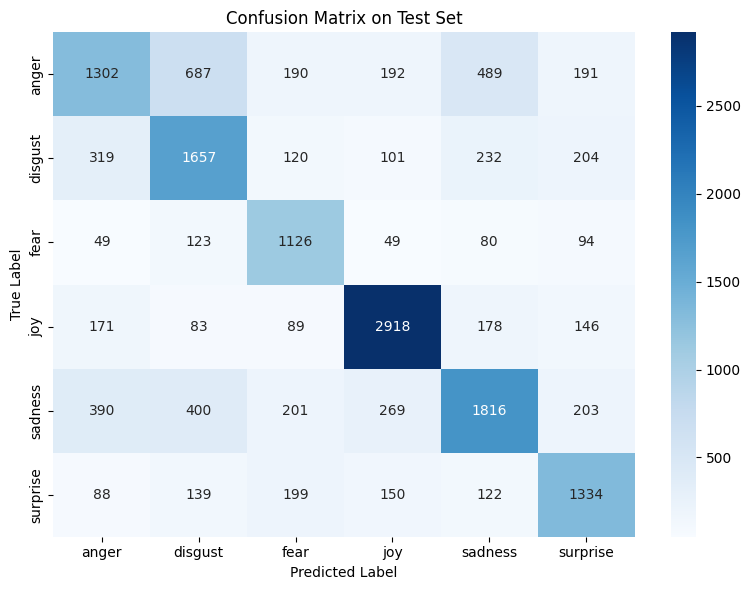

Executed cell #23


In [23]:
# ==========================================================
# CELL 22
# Generate and display confusion matrix for test predictions
# ==========================================================
print("Starting cell #23")

def plot_confusion_matrix(loader):
    model.eval()

    pred_labels = []
    true_labels = []

    with torch.no_grad():
        for batch in loader:
            model_inputs = {
                "input_ids_bengali": batch["Bengali_input_ids"].to(device),
                "attention_mask_bengali": batch["Bengali_attention_mask"].to(device),
                "input_ids_banglish": batch["Banglish_input_ids"].to(device),
                "attention_mask_banglish": batch["Banglish_attention_mask"].to(device),
                "input_ids_english": batch["English_input_ids"].to(device),
                "attention_mask_english": batch["English_attention_mask"].to(device)
            }

            outputs = model(**model_inputs)
            preds = torch.argmax(outputs["logits"], dim=1)

            pred_labels.extend(preds.cpu().numpy())
            true_labels.extend(batch["labels"].cpu().numpy())

    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix on Test Set")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(test_loader)
print("Executed cell #23")

Starting cell #24


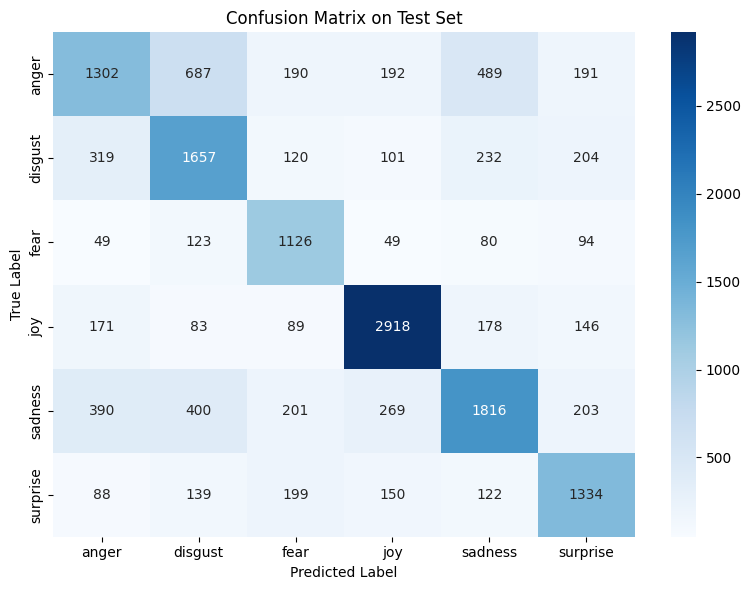

Executed cell #24


In [24]:
# ==========================================================
# CELL 23
# Call function to visualize confusion matrix
# ==========================================================
print("Starting cell #24")

plot_confusion_matrix(test_loader)
print("Executed cell #24")